In [2]:
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from pydantic import BaseModel
from dotenv import load_dotenv

In [3]:
load_dotenv()

True

In [4]:
model = ChatGroq(
    model="llama-3.3-70b-versatile"
)

In [5]:
class StudentState(TypedDict):
    name: str
    marks: int

    grade: str
    feedback: str

In [6]:
class Student(BaseModel):
    name: str
    marks: int

In [8]:
def validation_student(state: StudentState):
    Student(
        name= state["name"],
        marks=state["marks"]
    )
    print("validation complete")
    return state

In [12]:
def calculate_grade(state: StudentState):
    marks = state["marks"]
    if marks >= 80:
        state['grade'] = "A"
    elif marks >= 60:
        state['grade'] = "B"
    else:
        state["grade"] = "C"

    return state

In [13]:
def generate_feedback(state: StudentState):
    prompt = f"""
    Student Name: {state['name']}
    Marks: {state["marks"]}
    Grade: {state["grade"]}

    Generate a short teacher feedback.
    """

    response = model.invoke(prompt)
    state["feedback"] = response.content
    return state

In [14]:
def save_student(state: StudentState):
    print("saving Student")
    return state

In [15]:
builder = StateGraph(StudentState)

builder.add_node(
    "validation_student", 
    validation_student
)

builder.add_node(
    "calculate_grade",
    calculate_grade
)

builder.add_node(
    "generate_feedback",
    generate_feedback
)

builder.add_node(
    "save_student",
    save_student
)

In [16]:
builder.add_edge(
    START,
    'validation_student'
)

builder.add_edge(
    "validation_student",
    "calculate_grade"
)

builder.add_edge(
    "calculate_grade",
    "generate_feedback"
)

builder.add_edge(
    "generate_feedback",
    "save_student"
)

builder.add_edge(
    "save_student",
    END
)

In [17]:
graph = builder.compile()

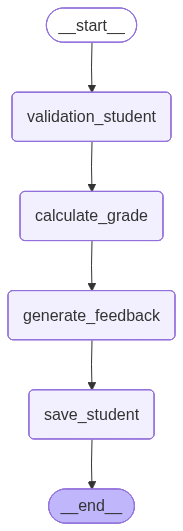

In [18]:
graph

In [19]:
result = graph.invoke(
    {
        "name": "mohit",
        "marks": 34
    }
)

validation complete
saving Student


In [20]:
print(result)

{'name': 'mohit', 'marks': 34, 'grade': 'C', 'feedback': '"Mohit, you have obtained 34 marks and a grade of C. While this is a decent effort, I encourage you to work on improving your understanding of the material and aim for higher scores in the future. With some extra practice and dedication, I am confident that you can achieve better results. Keep up the good work and let\'s work together to identify areas for improvement."'}
